## STEP 1: Import Required Libraries

Import all necessary Python libraries required for data analysis, visualization, preprocessing, and machine learning.

### Libraries used:

- **Pandas & NumPy** → Data handling and numerical operations  
- **Matplotlib & Seaborn** → Data visualization  
- **Scikit-learn** → Machine learning models, preprocessing, and evaluation  
- **Imbalanced-learn (SMOTE)** → Handling class imbalance in the dataset  
- **Warnings** → To ignore unnecessary warnings for cleaner output  

These libraries form the foundation of the HR Attrition prediction pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## STEP 2: Load and Explore the Dataset

Load the IBM HR Analytics Attrition dataset into a pandas DataFrame and perform basic exploration.

This step includes:
- Checking the dataset shape (rows and columns)
- Inspecting data types of each feature
- Checking for missing values
- Viewing sample records
- Analyzing the target variable (`Attrition`) distribution

The attrition dataset is imbalanced, with fewer employees leaving the company compared to those staying.

(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

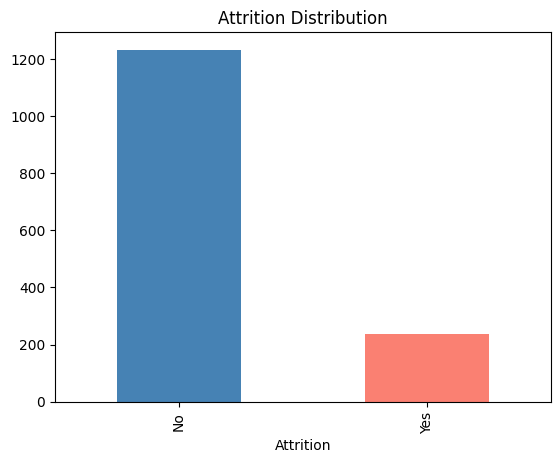

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic exploration
print(df.shape)          
print(df.dtypes)
print(df.isnull().sum()) # No nulls in this dataset
print(df.head())

# Check target class distribution
print(df['Attrition'].value_counts())
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Attrition Distribution')
plt.show()
df.head()

## STEP 3: Exploratory Data Analysis (EDA)

Perform exploratory data analysis to understand patterns, relationships, and factors influencing employee attrition.

This step includes:
- Visualizing attrition by overtime status
- Analyzing age distribution by attrition
- Examining correlations between numerical features
- Comparing monthly income across attrition groups

Key insights:
- Employees working overtime show higher attrition rates.
- Employees who left the company tend to be younger.
- Employees with lower monthly income are more likely to leave.
- Correlation analysis helps identify relationships between numerical variables.

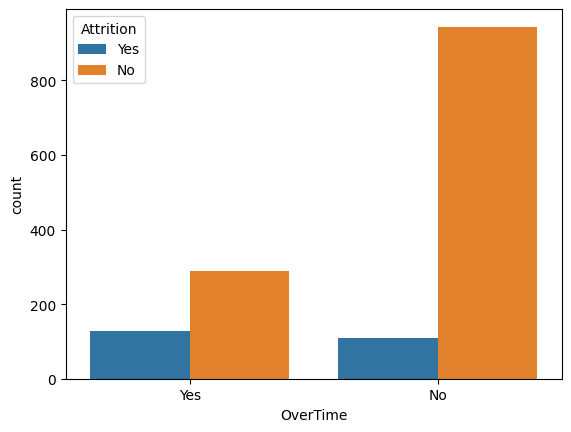

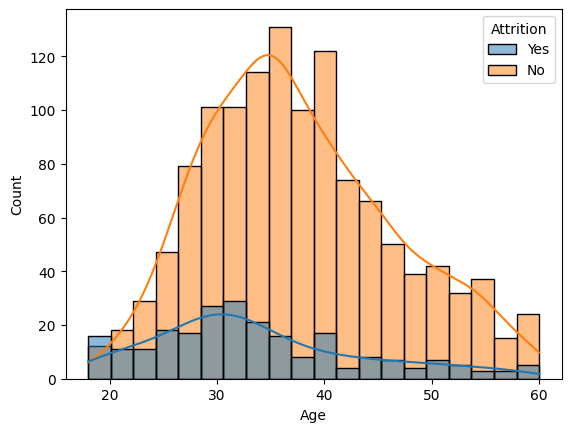

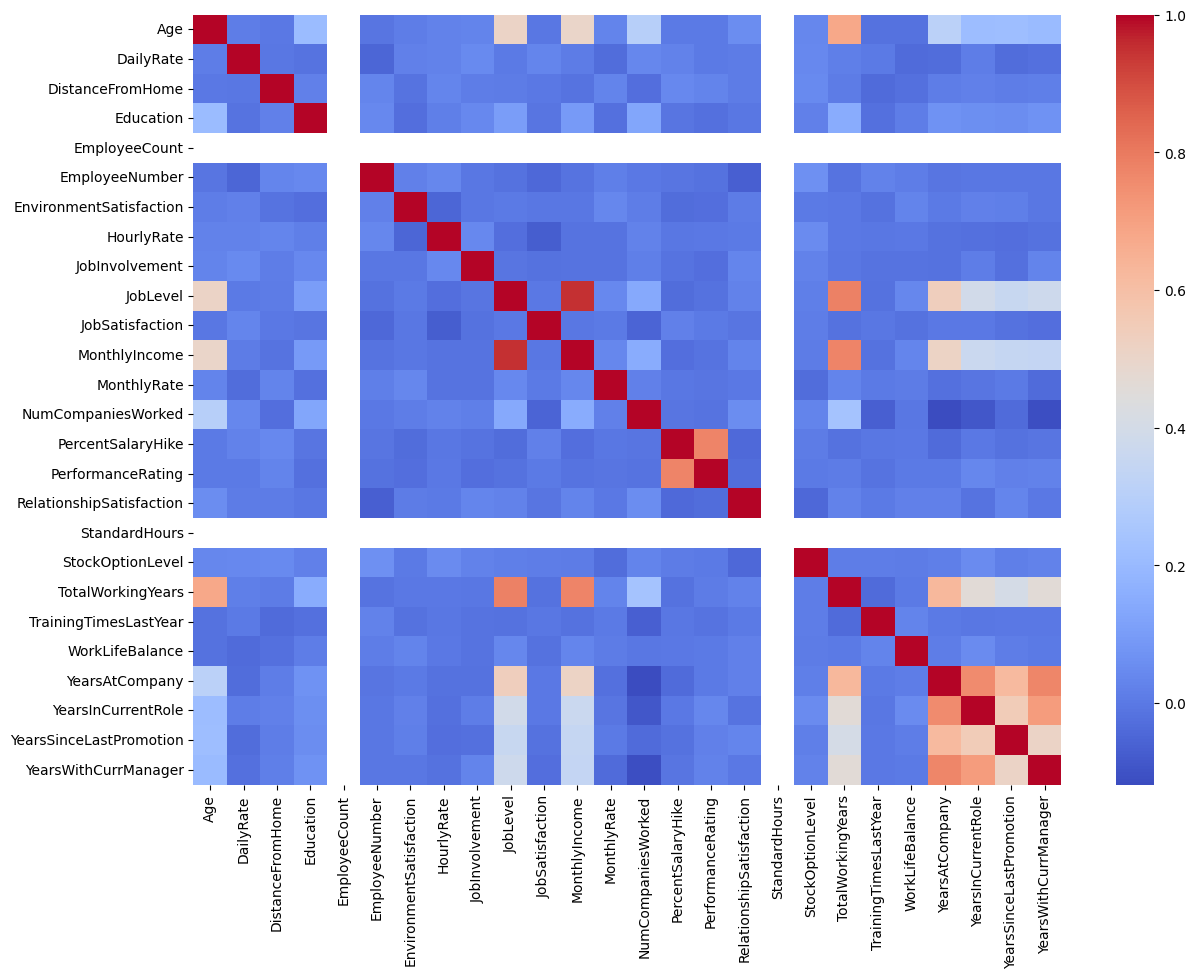

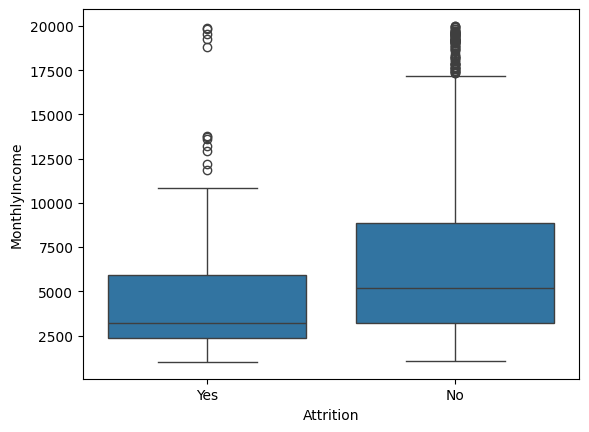

In [3]:
# Attrition by OverTime (strong predictor)
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.show()

# Attrition by Age group
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, kde=True)
plt.show()

# Correlation heatmap (numeric columns)
numeric_df = df.select_dtypes(include=['int64'])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.show()

# Box plot — Monthly Income vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

## STEP 4: Data Preprocessing

Remove unnecessary columns that do not contribute to employee attrition prediction.

The following columns are dropped:
- `EmployeeCount`
- `EmployeeNumber`
- `StandardHours`
- `Over18`

These columns contain constant values or unique identifiers that are not useful for machine learning models.

In [4]:
# Drop unnecessary columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber',
                      'StandardHours', 'Over18'], errors='ignore')

print(df.shape)

(1470, 31)


## STEP 5: Encode Categorical Variables and Prepare Features

In this step, we prepare the dataset for machine learning by converting categorical variables into numerical format.

We perform the following operations:
- Convert the target variable (Attrition) into binary format (Yes → 1, No → 0)
- Separate features (X) and target (y)
- Apply One-Hot Encoding to all categorical variables
- Save feature column names for future predictions

One-Hot Encoding is used to avoid ordinal relationships between categories and improves model performance for classification tasks.

In [5]:
# Convert target column
df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0})

# Split features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Identify categorical columns
cat_cols = X.select_dtypes(include='object').columns

# One-Hot Encoding (BEST PRACTICE)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Save feature columns for later use (VERY IMPORTANT for Step 9)
feature_columns = X.columns

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:\n", y.value_counts())

X shape: (1470, 44)
y shape: (1470,)

Class distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64


## STEP 6: Train-Test Split, SMOTE, and Feature Scaling

This step prepares the dataset for machine learning by handling class imbalance and normalizing features.

### 1. Train-Test Split
- The dataset is split into training and testing sets (80/20 split)
- `stratify=y` ensures both sets maintain the same class distribution

### 2. Handling Class Imbalance (SMOTE)
- SMOTE (Synthetic Minority Oversampling Technique) is applied only on the training data
- It generates synthetic samples for the minority class (Attrition = Yes)
- This prevents model bias toward the majority class

### 3. Feature Scaling
- StandardScaler is used to normalize features
- Ensures all features have equal importance in distance-based models
- Scaling is applied after SMOTE:
  - Fit on training data only
  - Transform both training and test data

### Output:
- Balanced training dataset
- Scaled feature sets ready for model training

In [6]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(1470, 44)
(1470,)
Attrition
0    1233
1     237
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}


In [8]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print(X_train_scaled.shape)
print(X_test_scaled.shape)

Scaling complete
(1972, 44)
(294, 44)


## STEP 7: Model Training and Evaluation

In this step, multiple machine learning models are trained to predict employee attrition.

### Models Used:
- Logistic Regression (baseline model)
- Random Forest Classifier
- Gradient Boosting Classifier

### Process:
- Each model is trained using the scaled training data
- Predictions are made on the test dataset
- Probability outputs are used for ROC-AUC calculation

### Evaluation Metrics:
- **Accuracy** → Overall correctness of predictions  
- **ROC-AUC Score** → Measures model’s ability to distinguish between classes  
- **Classification Report** → Includes Precision, Recall, and F1-score

### Key Insight:
ROC-AUC is more important than accuracy for this problem because the dataset is imbalanced.

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_bal)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_proba)
    }
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.57      0.43      0.49        47

    accuracy                           0.86       294
   macro avg       0.73      0.68      0.70       294
weighted avg       0.84      0.86      0.85       294


Random Forest
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       247
           1       0.39      0.19      0.26        47

    accuracy                           0.82       294
   macro avg       0.63      0.57      0.58       294
weighted avg       0.78      0.82      0.80       294


Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.54      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.72      0.67      0.69       294
weighted avg       

## STEP 8: Model Evaluation (Best Model Analysis)

In this step, the best-performing model (Random Forest) is evaluated using multiple performance metrics and visualizations.

### 1. Confusion Matrix
- Shows correct vs incorrect predictions
- Helps understand model performance on both classes (Yes/No Attrition)

### 2. ROC Curve
- Plots True Positive Rate vs False Positive Rate
- AUC (Area Under Curve) indicates how well the model distinguishes between employees who leave and those who stay

### 3. Feature Importance
- Identifies the most important features influencing employee attrition
- Helps understand key business drivers such as income, job role, and overtime

### Key Insight:
Feature importance helps HR teams focus on factors that most influence employee retention.

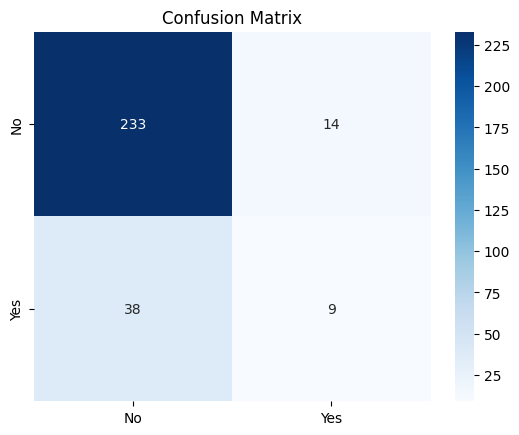

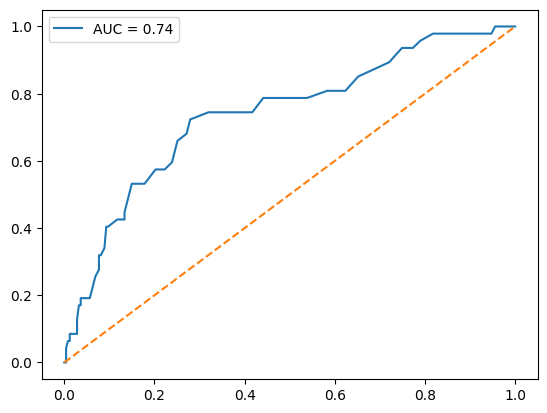

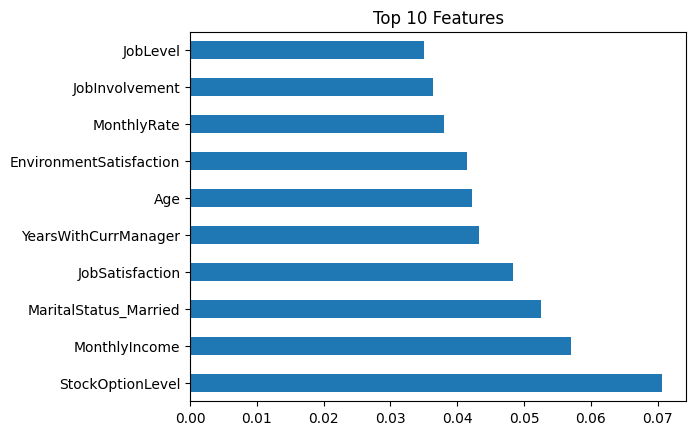

In [10]:
best_model = models['Random Forest']
y_pred  = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Confusion Matrix'); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1],'--'); plt.legend(); plt.show()

# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features'); plt.show()

## STEP 9: Prediction on New Employee Data

In this step, the trained model is used to predict attrition risk for a new employee.

### Process:

- A new employee record is created using sample feature values  
- The input features are aligned to match the training dataset column structure (including One-Hot Encoded features)  
- The same scaler used during training is applied to transform the data  
- The trained model predicts the probability of attrition  

### Output:
- The final result shows the probability of whether the employee is likely to leave the company  

### Key Insight:
This step demonstrates how the trained machine learning model can be used in real-world HR decision-making systems.

In [11]:
new_employee = pd.DataFrame([{
    'Age': 32,
    'BusinessTravel': 1,
    'DailyRate': 800,
    'Department': 2,
    'DistanceFromHome': 10,
    'Education': 3,
    'EducationField': 2,
    'EnvironmentSatisfaction': 2,
    'Gender': 1,
    'HourlyRate': 65,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 4,
    'JobSatisfaction': 2,
    'MaritalStatus': 1,
    'MonthlyIncome': 4000,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 3,
    'OverTime': 1,
    'PercentSalaryHike': 11,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 3,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 8,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 3,
    'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 2
}])

# Match training column order
new_employee = new_employee.reindex(columns=feature_columns, fill_value=0)

# Scale
new_scaled = scaler.transform(new_employee)

# Predict
prob = best_model.predict_proba(new_scaled)[0][1]

print(f"Attrition risk: {prob:.1%}")

Attrition risk: 90.0%
